In [1]:
# 导入需要的工具箱
import pandas as pd              # 处理表格数据
import numpy as np               # 数学计算
import matplotlib.pyplot as plt  # 画图
import seaborn as sns            # 更漂亮的图

# 读取 CSV 文件，存到变量 df 里
df = pd.read_csv('SEER_Breast_Cancer_Dataset.csv')

# 显示前 5 行
df.head()


,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),NaN,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead


In [2]:
# 数据有多少行、多少列
print(f"样本量: {df.shape[0]} 位患者")
print(f"变量数: {df.shape[1]} 个临床指标")
print("-" * 50)

# 每一列的数据类型 + 有没有缺失
df.info()


样本量: 4024 位患者
变量数: 16 个临床指标
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4024 non-null   int64  
 1   Race                    4024 non-null   object 
 2   Marital Status          4024 non-null   object 
 3   Unnamed: 3              0 non-null      float64
 4   T Stage                 4024 non-null   object 
 5   N Stage                 4024 non-null   object 
 6   6th Stage               4024 non-null   object 
 7   Grade                   4024 non-null   object 
 8   A Stage                 4024 non-null   object 
 9   Tumor Size              4024 non-null   int64  
 10  Estrogen Status         4024 non-null   object 
 11  Progesterone Status     4024 non-null   object 
 12  Regional Node Examined  4024 non-null   int64  
 13  Reginol Node P

In [3]:
# 数值列的统计描述（平均值、最大最小值等）
df.describe()


,Age,Unnamed: 3,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,0.0,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,NaN,30.473658,14.357107,4.158052,71.297962
std,8.963134,NaN,21.119696,8.099675,5.109331,22.921430
min,30.000000,NaN,1.000000,1.000000,1.000000,1.000000
25%,47.000000,NaN,16.000000,9.000000,1.000000,56.000000
50%,54.000000,NaN,25.000000,14.000000,2.000000,73.000000
75%,61.000000,NaN,38.000000,19.000000,5.000000,90.000000
max,69.000000,NaN,140.000000,61.000000,46.000000,107.000000


In [4]:
# 修正数据集的拼写错误：Reginol → Regional
df = df.rename(columns={'Reginol Node Positive': 'Regional Node Positive'})

# 验证一下改名成功
print(df.columns.tolist())


['Age', 'Race ', 'Marital Status', 'Unnamed: 3', 'T Stage ', 'N Stage', '6th Stage', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Regional Node Positive', 'Survival Months', 'Status']


In [5]:
# 复制一份数据，保留原始数据不动（万一洗坏了还能重来）
df_clean = df.copy()

# 记录清洗前的样本量
print(f"清洗前: {len(df_clean)} 位患者")

# ① 删除完全重复的行
df_clean = df_clean.drop_duplicates()

# ② 删除 SEER 的"未知"编码
df_clean = df_clean[df_clean['Tumor Size'] != 999]
df_clean = df_clean[df_clean['Regional Node Examined'] != 99]
df_clean = df_clean[df_clean['Regional Node Positive'] != 99]

# ③ 删除生存时间为 0 的记录
df_clean = df_clean[df_clean['Survival Months'] > 0]

# ④ 重置索引（删完数据后序号会乱，重排一下）
df_clean = df_clean.reset_index(drop=True)

print(f"清洗后: {len(df_clean)} 位患者")
print(f"删掉了 {len(df) - len(df_clean)} 条记录")


清洗前: 4024 位患者
清洗后: 4023 位患者
删掉了 1 条记录


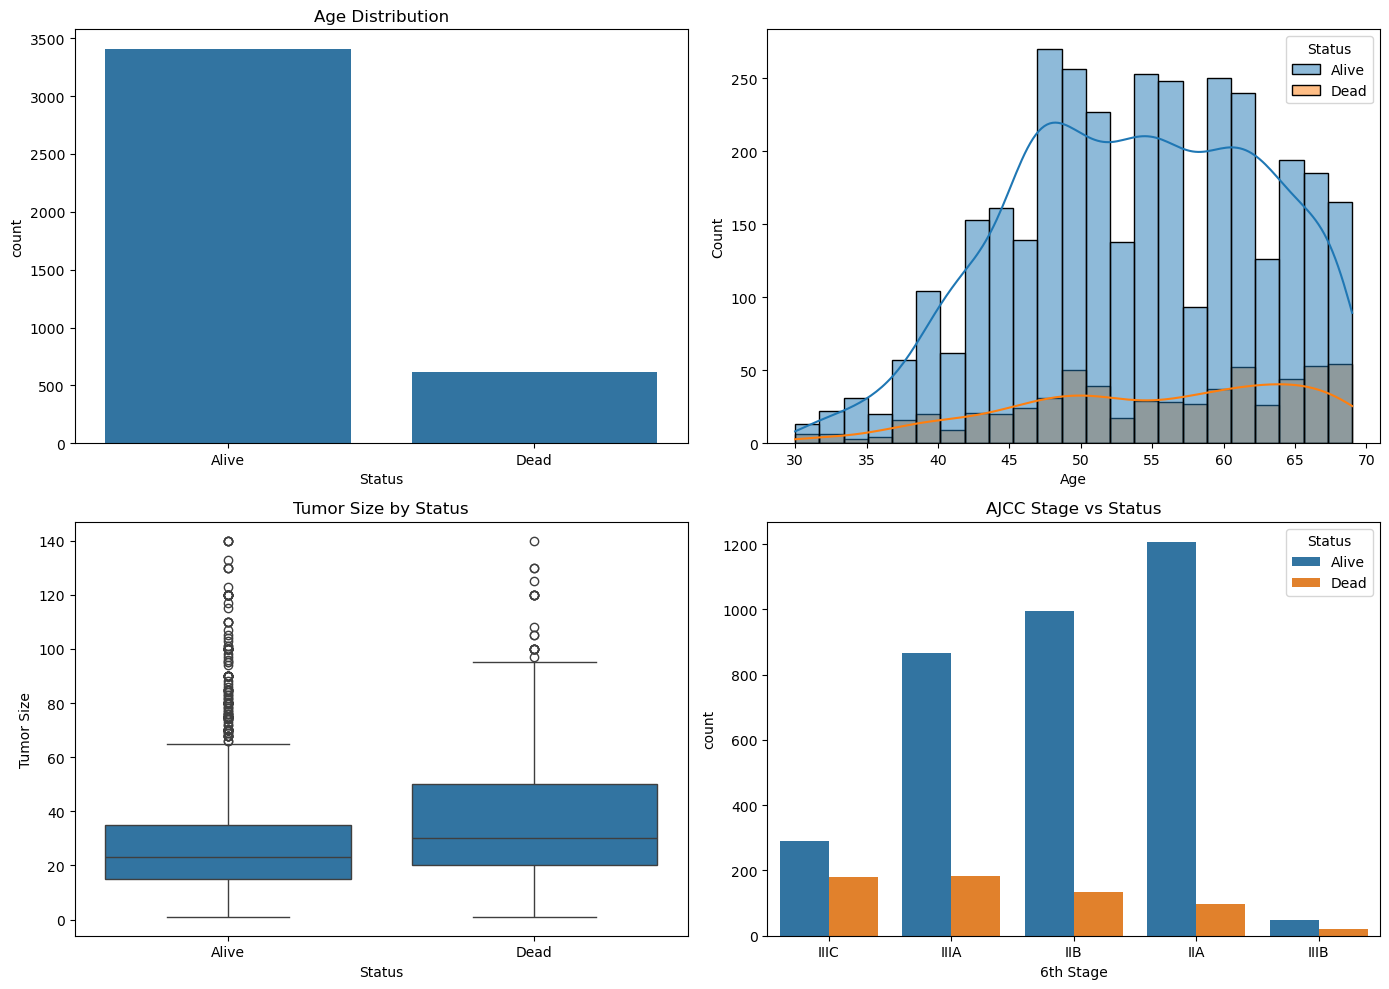

In [6]:
# 设置图片清晰度
plt.rcParams['figure.dpi'] = 100

# 画 2x2 的四张图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图 1：生存和死亡的人数对比
sns.countplot(x='Status', data=df_clean, ax=axes[0,0])
axes[0,0].set_title('Alive vs Dead')

# 图 2：不同年龄的生存情况
sns.histplot(data=df_clean, x='Age', hue='Status', kde=True, ax=axes[0,1])
axes[0,0].set_title('Age Distribution')

# 图 3：肿瘤大小 vs 生存状态
sns.boxplot(data=df_clean, x='Status', y='Tumor Size', ax=axes[1,0])
axes[1,0].set_title('Tumor Size by Status')

# 图 4：不同分期的生存情况
sns.countplot(data=df_clean, x='6th Stage', hue='Status', ax=axes[1,1])
axes[1,1].set_title('AJCC Stage vs Status')

plt.tight_layout()
plt.show()


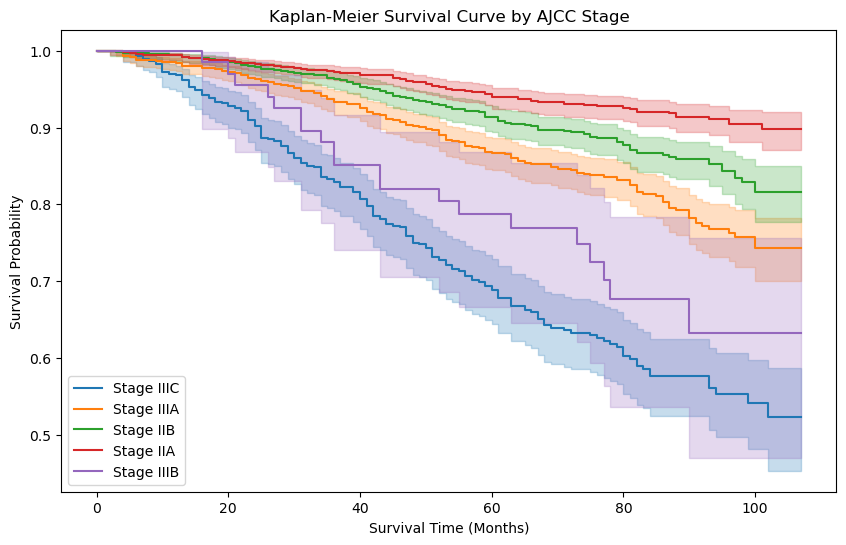

In [7]:
# 导入生存分析工具
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

# 按 AJCC 分期分别画生存曲线
for stage in df_clean['6th Stage'].unique():
    mask = df_clean['6th Stage'] == stage
    kmf.fit(df_clean[mask]['Survival Months'], 
            df_clean[mask]['Status'].apply(lambda x: 1 if x=='Dead' else 0),
            label=f'Stage {stage}')
    kmf.plot_survival_function(ax=ax)

ax.set_title('Kaplan-Meier Survival Curve by AJCC Stage')
ax.set_xlabel('Survival Time (Months)')
ax.set_ylabel('Survival Probability')
plt.savefig('forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# 去掉所有列名首尾的隐形空格
# （Reginol→Regional 早已改名，这里不用重复改）
df_clean.columns = df_clean.columns.str.strip()

# 看看修复后的列名
print(df_clean.columns.tolist())

['Age', 'Race', 'Marital Status', 'Unnamed: 3', 'T Stage', 'N Stage', '6th Stage', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Regional Node Positive', 'Survival Months', 'Status']


In [9]:
# 1. 从清洗好的数据出发（列名前面已 strip + 改名过，无需重复处理）
df_model = df_clean.copy()

# 2. 生成事件列 + One-Hot 编码
df_model['event'] = (df_model['Status'] == 'Dead').astype(int)
categorical_cols = ['Race', 'Marital Status', 'T Stage', 'N Stage',
                    '6th Stage', 'Grade', 'A Stage',
                    'Estrogen Status', 'Progesterone Status']
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_encoded = df_encoded.drop(columns=['Status'])

# 3. 删除空列
ghost_cols = [c for c in df_encoded.columns if c.startswith('Unnamed')]
if ghost_cols:
    df_encoded = df_encoded.drop(columns=ghost_cols)
    print(f"已删除空列: {ghost_cols}")

# 4. 删除真正的缺失值
n_before = len(df_encoded)
df_encoded = df_encoded.dropna()

print(f"重建完成：{n_before} 位患者 → {len(df_encoded)} 位患者，共 {df_encoded.shape[1]} 个变量")

# 5. 自动体检：人数不对就大声报警
if len(df_encoded) < 3000:
    print("⚠️ 警告：患者数异常偏少，先别往下跑，把这条输出发给助手！")
else:
    print("✅ 数据就绪，可以继续 train_test_split 了")

已删除空列: ['Unnamed: 3']
重建完成：4023 位患者 → 4023 位患者，共 27 个变量
✅ 数据就绪，可以继续 train_test_split 了


In [10]:
from sklearn.model_selection import train_test_split

# 80% 训练，20% 测试；random_state=42 保证每次运行划分一样（可复现）
train_df, test_df = train_test_split(df_encoded, 
                                      test_size=0.2, 
                                      random_state=42,
                                      stratify=df_encoded['event'])

print(f"训练集: {len(train_df)} 位患者")
print(f"测试集: {len(test_df)} 位患者")


训练集: 3218 位患者
测试集: 805 位患者


In [11]:
from lifelines import CoxPHFitter

# 建立模型（penalizer 防过拟合
cph = CoxPHFitter(penalizer=0.01)

# 训练模型：喂入训练集，指定"生存时间"列和"是否死亡"列
cph.fit(train_df, duration_col='Survival Months', event_col='event')

# 输出详细结果表格
cph.print_summary(decimals=3)


<lifelines.CoxPHFitter: fitted with 3218 total observations, 2725 right-censored observations>
             duration col = 'Survival Months'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3218
number of events observed = 493
   partial log-likelihood = -3629.566
         time fit was run = 2026-10-03 07:23:42 UTC

---
                                                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                        
Age                                                             0.017     1.017     0.005           0.006           0.027               1.006               1.027
Tumor Size                                                      0.004     1.004     0.003          -0.002           0.010               0.998               1.010
Regional Node Examined                                         -0.030     0.970     0.007          -0.043          -0.017               0.958               0.983
Regional Node Positive                                          0.049     1.051     0.011           0.027           0.072               1.027               1.075
Race_Other (American Indian/AK Native, Asian/Pacific Islander) -0.634     0.531     0.225          -1.075          -0.192               0.341               0.825
Race_White                                                     -0.234     0.791     0.142          -0.513           0.045               0.598               1.046
Marital Status_Married (including common law)                  -0.169     0.845     0.122          -0.407           0.069               0.665               1.072
Marital Status_Separated                                        0.363     1.438     0.305          -0.235           0.962               0.790               2.617
Marital Status_Single (never married)                          -0.032     0.968     0.149          -0.325           0.260               0.722               1.297
Marital Status_Widowed                                         -0.088     0.916     0.195          -0.470           0.295               0.625               1.343
T Stage_T2                                                      0.241     1.273     0.140          -0.034           0.516               0.967               1.676
T Stage_T3                                                      0.134     1.143     0.223          -0.303           0.571               0.739               1.770
T Stage_T4                                                      0.599     1.821     0.290           0.031           1.167               1.032               3.214
N Stage_N2                                                      0.418     1.519     0.186           0.054           0.782               1.056               2.186
N Stage_N3                                                      0.409     1.505     0.398          -0.371           1.188               0.690               3.280
6th Stage_IIB                                                   0.135     1.145     0.178          -0.214           0.484               0.807               1.623
6th Stage_IIIA                                                  0.175     1.191     0.208          -0.234           0.583               0.792               1.791
6th Stage_IIIB                                                  0.014     1.014     0.392          -0.755           0.783               0.470               2.188
6th Stage_IIIC                                                  0.409     1.505     0.398          -0.371           1.188               0.690               3.280
Grade_Poorly differentiated; Grade III                          0.350     1.419     0.096           0.161           0.539               1.175               1.71

In [12]:
from lifelines.utils import concordance_index

# 在训练集上打分
train_cindex = concordance_index(train_df['Survival Months'], 
                                  -cph.predict_partial_hazard(train_df), 
                                  train_df['event'])

# 在测试集上打分
test_cindex = concordance_index(test_df['Survival Months'], 
                                 -cph.predict_partial_hazard(test_df), 
                                 test_df['event'])

print(f"Cox 训练集 C-index: {train_cindex:.3f}")
print(f"Cox 测试集 C-index: {test_cindex:.3f}")


Cox 训练集 C-index: 0.744
Cox 测试集 C-index: 0.734


In [13]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

# scikit-survival 需要特殊格式的标签
y_train = Surv.from_arrays(event=train_df['event'].astype(bool), 
                            time=train_df['Survival Months'])
y_test = Surv.from_arrays(event=test_df['event'].astype(bool), 
                           time=test_df['Survival Months'])

X_train = train_df.drop(columns=['Survival Months', 'event'])
X_test = test_df.drop(columns=['Survival Months', 'event'])

# 训练随机生存森林
rsf = RandomSurvivalForest(n_estimators=300,
                            max_depth=8,
                            min_samples_split=10,
                            min_samples_leaf=5,
                            n_jobs=-1,
                            random_state=42)
rsf.fit(X_train, y_train)

# 打分（存成变量，后面画图、特征重要性直接复用，不用重复算）
rsf_train_cindex = rsf.score(X_train, y_train)
rsf_test_cindex = rsf.score(X_test, y_test)
print(f"RSF 训练集 C-index: {rsf_train_cindex:.3f}")
print(f"RSF 测试集 C-index: {rsf_test_cindex:.3f}")

RSF 训练集 C-index: 0.820
RSF 测试集 C-index: 0.721


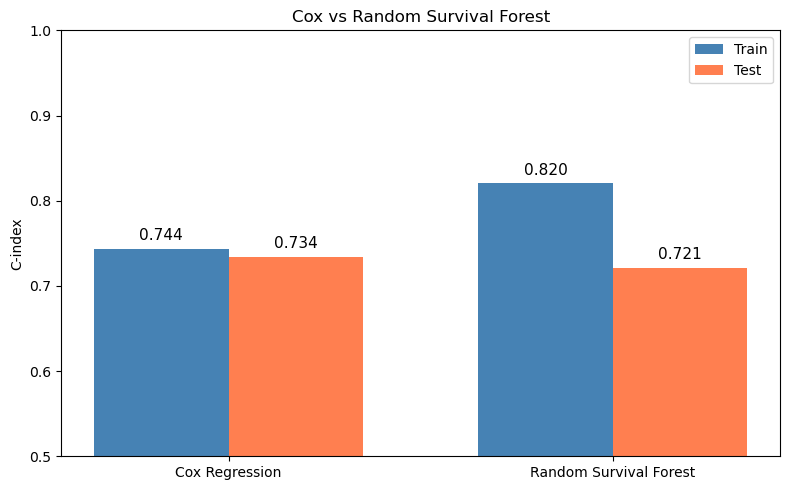

In [14]:
# 画两个模型的对比柱状图（RSF 分数直接用上一格存好的变量）
models = ['Cox Regression', 'Random Survival Forest']
train_scores = [train_cindex, rsf_train_cindex]
test_scores = [test_cindex, rsf_test_cindex]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_scores, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, test_scores, width, label='Test', color='coral')

# 在柱子上标数字
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.3f}', ha='center', fontsize=11)

ax.set_ylabel('C-index')
ax.set_title('Cox vs Random Survival Forest')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)  # 保存高清图到本地
plt.show()

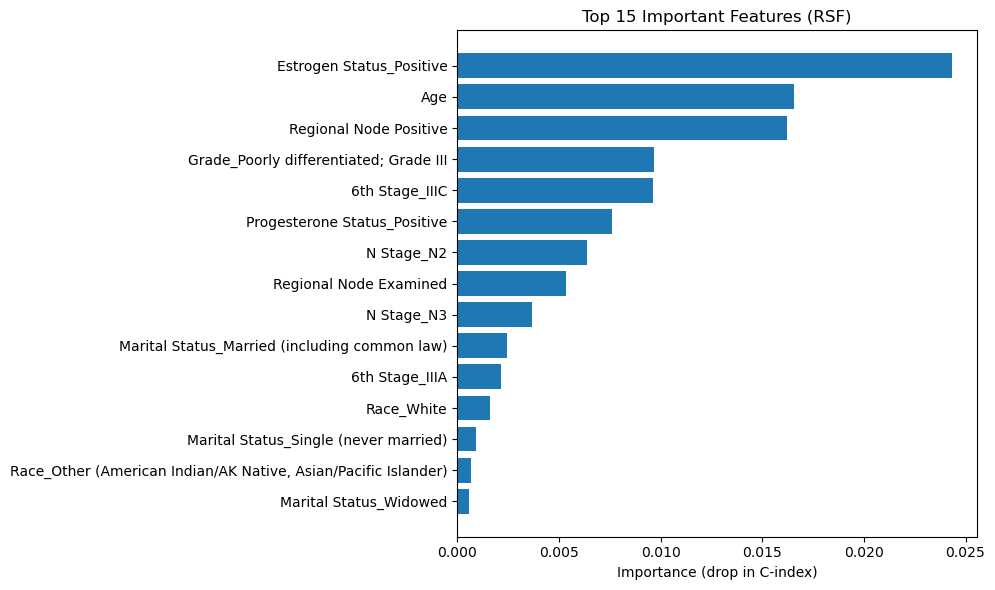

                                              feature  importance
23                           Estrogen Status_Positive    0.024330
0                                                 Age    0.016545
3                              Regional Node Positive    0.016212
19             Grade_Poorly differentiated; Grade III    0.009671
18                                     6th Stage_IIIC    0.009606
24                       Progesterone Status_Positive    0.007618
13                                         N Stage_N2    0.006374
2                              Regional Node Examined    0.005335
14                                         N Stage_N3    0.003655
6       Marital Status_Married (including common law)    0.002463
16                                     6th Stage_IIIA    0.002129
5                                          Race_White    0.001616
8               Marital Status_Single (never married)    0.000936
4   Race_Other (American Indian/AK Native, Asian/P...    0.000680
9         

In [15]:
# 手动计算每个特征的重要性（打乱该特征后看模型变差多少）
# pandas / numpy 前面已导入；baseline 直接复用 RSF 那格算好的测试集分数
importance_results = []
baseline = rsf_test_cindex

for col in X_test.columns:
    X_temp = X_test.copy()
    X_temp[col] = np.random.permutation(X_temp[col])  # 打乱这一列
    score = rsf.score(X_temp, y_test)
    importance_results.append({'feature': col, 
                                'importance': baseline - score})

# 排序取最重要的前 15 个
imp_df = pd.DataFrame(importance_results).sort_values('importance', ascending=False).head(15)

# 画图
plt.figure(figsize=(10, 6))
plt.barh(imp_df['feature'], imp_df['importance'])
plt.xlabel('Importance (drop in C-index)')
plt.title('Top 15 Important Features (RSF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print(imp_df)

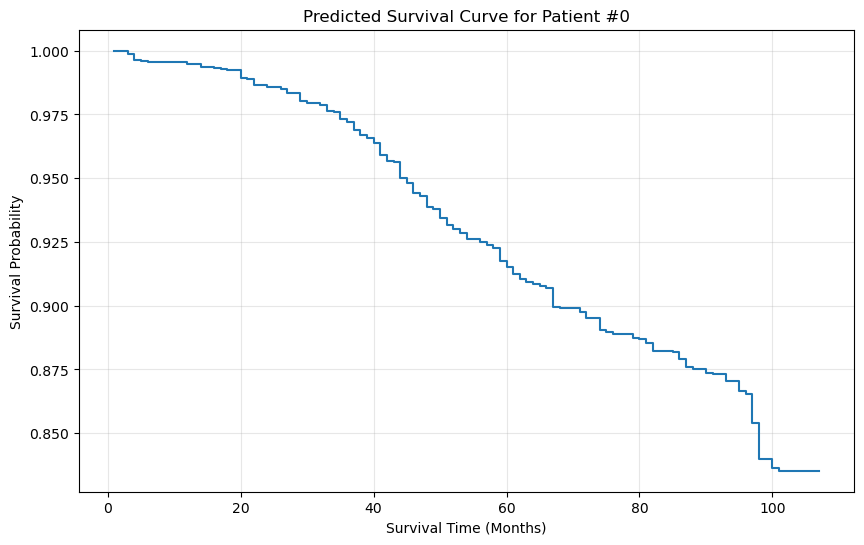

5 年生存率预测: 91.5%
8 年生存率预测: 86.6%
最大随访时间: 107 个月


In [16]:
# 取测试集的第 1 个患者，预测 TA 的生存曲线
sample = X_test.iloc[[0]]
surv_pred = rsf.predict_survival_function(sample)

# 画这个患者的预测生存曲线
plt.figure(figsize=(10, 6))
for s in surv_pred:
    plt.step(s.x, s.y, where='post')
plt.xlabel('Survival Time (Months)')
plt.ylabel('Survival Probability')
plt.title('Predicted Survival Curve for Patient #0')
plt.grid(True, alpha=0.3)
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印关键时间点（数据最长随访 107 个月，只能预测到 8 年）
print(f"5 年生存率预测: {surv_pred[0](60):.1%}")
print(f"8 年生存率预测: {surv_pred[0](96):.1%}")
print(f"最大随访时间: {surv_pred[0].x[-1]:.0f} 个月")
